In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- DARK THEME CONFIG ---
BASE_LIGHT = palette = sns.color_palette("Set2")[-1]
BASE_DARK = palette = sns.color_palette("Set2")[-1]
FT_LIGHT = sns.color_palette()[0]
FT_DARK = '#58A6FF'
FN_LIGHT = sns.color_palette()[1] 
FN_DARK = '#F78166'
GITHUB_BG_DARK = '#0D1117' 
GITHUB_TEXT_DARK = '#C9D1D9'
SUCCESS = '#3FB950'
FAIL = '#FF7B72'

DARK_PARAMS = {
    "figure.facecolor": GITHUB_BG_DARK,
    "axes.facecolor": GITHUB_BG_DARK,
    "text.color": GITHUB_TEXT_DARK,
    "axes.labelcolor": GITHUB_TEXT_DARK,
    "xtick.color": GITHUB_TEXT_DARK,
    "ytick.color": GITHUB_TEXT_DARK,
    "axes.edgecolor": GITHUB_TEXT_DARK,
    "grid.color": "#21262D", 
    "grid.alpha": 0.5,
}

# --- LIGHT THEME CONFIG ---
GITHUB_BG_LIGHT = '#FFFFFF' 
GITHUB_TEXT_LIGHT = '#24292F'

LIGHT_PARAMS = {
    "figure.facecolor": GITHUB_BG_LIGHT,
    "axes.facecolor": GITHUB_BG_LIGHT,
    "text.color": GITHUB_TEXT_LIGHT,
    "axes.labelcolor": GITHUB_TEXT_LIGHT,
    "xtick.color": GITHUB_TEXT_LIGHT,
    "ytick.color": GITHUB_TEXT_LIGHT,
    "axes.edgecolor": GITHUB_TEXT_LIGHT,
    "grid.color": "#D0D7DE", 
    "grid.alpha": 0.8,
}

def set_theme(mode='dark'):
    """Switches the plot's style between 'dark' (GitHub) and 'light' (standard)."""
    
    if mode == 'dark':
        sns.set_theme(style="darkgrid")
        plt.rcParams.update(DARK_PARAMS)
    
    elif mode == 'light':
        sns.set_theme(style="whitegrid")
        plt.rcParams.update(LIGHT_PARAMS)
    
    else:
        raise ValueError("Mode must be 'dark' or 'light'")
    
def plot_loss(dfs: [pd.DataFrame], 
              palette: [str],
              labels: [str],
              theme: str = 'dark', 
              save_path: str = None):
    set_theme(theme)
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for df, c, label in zip(dfs, palette, labels):
        df["Smooth Loss"] = df["Loss"].ewm(span=20).mean()
        sns.lineplot(df, x="Step", y="Loss", c=c, alpha=0.25, label=label, ax=ax)
        sns.lineplot(df, x="Step", y="Smooth Loss", c=c, ax=ax)
    
    ax.set_title("Fine-tuning with Multiple Negatives Ranking Loss", fontsize=16)
    ax.legend(title="")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(
            save_path, 
            dpi=300,
            bbox_inches='tight',
            transparent=False,
            facecolor=plt.rcParams['figure.facecolor']
        )
    plt.show()
    
def plot_metrics_barplot(df: pd.DataFrame, 
                         palette: [str], 
                         ylims: tuple = (0, 1), 
                         theme: str = 'dark', 
                         save_path : str = None):
    set_theme(theme)
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(df, x="Metric", y="Value", hue="Model", palette=palette, ax=ax)
    ax.set_ylim(ylims)
    for p in ax.patches:
        ax.annotate(
            format(p.get_height(), '.3f'), 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha = 'center', 
            va = 'center', 
            xytext = (0, 9), 
            textcoords = 'offset points'
        )
    
    ax.set_title("Evaluation Metrics for Different Models on CoSQA Dataset", fontsize=16)
    ax.legend(title="")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(
            save_path, 
            dpi=300,
            bbox_inches='tight',
            transparent=False,
            facecolor=plt.rcParams['figure.facecolor']
        )
    plt.show()

def plot_metrics_improvement(df: pd.DataFrame,
                             color: str,
                             theme: str = 'dark',
                             save_path: str = None):
    set_theme(theme)
    df_diff = df.pivot(index="Metric", columns="Model", values="Value")
    df_diff["Absolute_Gain"] = df_diff["Fine-Tuned Model"] - df_diff["Base Model"]
    df_diff["Percent_Gain"] = (df_diff["Absolute_Gain"] / df_diff["Base Model"]) * 100
    df_plot = df_diff.reset_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        x="Metric", 
        y="Percent_Gain", 
        data=df_plot,
        ax=ax
    )
    ax.set_title("Percentage Improvement over Base Model", fontsize=16)
    ax.set_ylabel("Percentage Gain (%)")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(
            save_path, 
            dpi=300,
            bbox_inches='tight',
            transparent=False,
            facecolor=plt.rcParams['figure.facecolor']
        )
    plt.show()

# Fine-Tuning

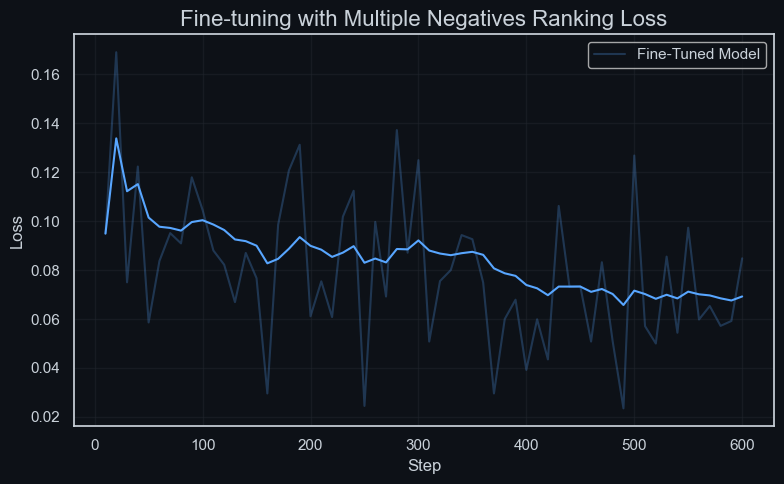

In [2]:
df = pd.read_csv("results/losses.csv")
# plot_loss([df],
#           palette=[FT_LIGHT],
#           labels=["Fine-Tuned Model"],
#           theme='light',
#           save_path='assets/loss_ft_light.png')
plot_loss([df],
          palette=[FT_DARK],
          labels=["Fine-Tuned Model"],
          theme='dark',
          save_path='assets/loss_ft_dark.png')

# Evaluation

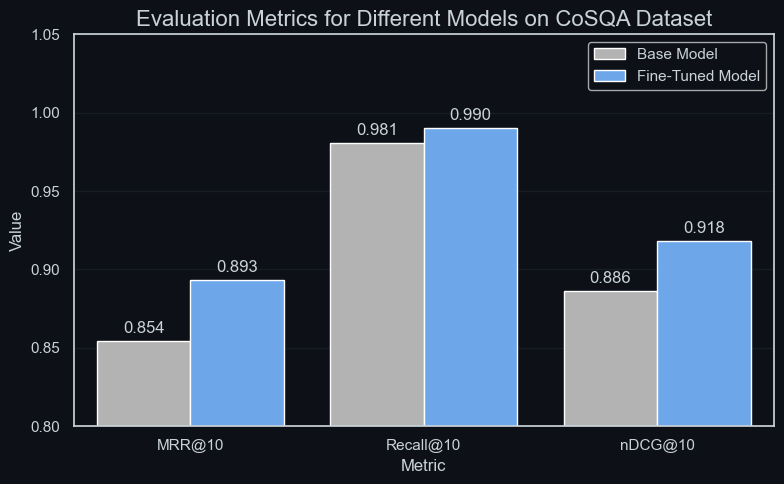

In [3]:
df = pd.read_csv("results/evaluation.csv").drop(columns=["Avg. Query Time (ms)"])
df = df.melt(id_vars="Model", value_vars=["MRR@10", "Recall@10", "nDCG@10"], var_name="Metric", value_name="Value")

ylims = (0.8, 1.05)
# plot_metrics_barplot(df, 
#                      [BASE_LIGHT, FT_LIGHT], 
#                      ylims=ylims, 
#                      theme="light", 
#                      save_path="assets/eval_ft_light.png"
# )
plot_metrics_barplot(df, 
                     [BASE_DARK, FT_DARK], 
                     ylims=ylims, 
                     theme="dark", 
                     save_path="assets/eval_ft_dark.png"
)

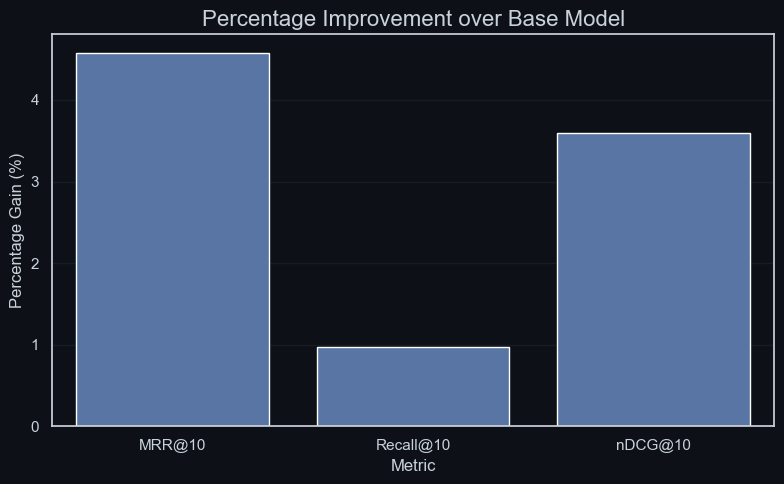

In [4]:
df = pd.read_csv("results/evaluation.csv").drop(columns=["Avg. Query Time (ms)"])
df = df.melt(id_vars="Model", value_vars=["MRR@10", "Recall@10", "nDCG@10"], var_name="Metric", value_name="Value")
# plot_metrics_improvement(df,
#                          color=FT_LIGHT,
#                          theme='light',
#                          save_path='assets/improvement_ft_light.png'
# )
plot_metrics_improvement(df,
                         color=FT_DARK,
                         theme='dark',
                         save_path='assets/improvement_ft_dark.png'
)

# Fine-Tuning with Function Names

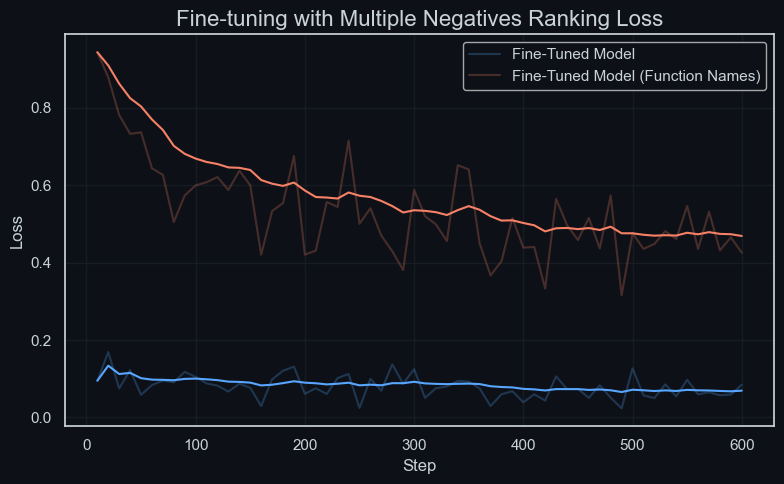

In [5]:
dfs = [pd.read_csv("results/losses.csv"), 
       pd.read_csv("results/losses_fn_names.csv")]
       
# plot_loss(dfs,
#           palette=[FT_LIGHT, FN_LIGHT],
#           labels=["Fine-Tuned Model", "Fine-Tuned Model (Function Names)"],
#           theme='light',
#           save_path='assets/loss_fn_light.png')
plot_loss(dfs,
          palette=[FT_DARK, FN_DARK],
          labels=["Fine-Tuned Model", "Fine-Tuned Model (Function Names)"],
          theme='dark',
          save_path='assets/loss_fn_dark.png')

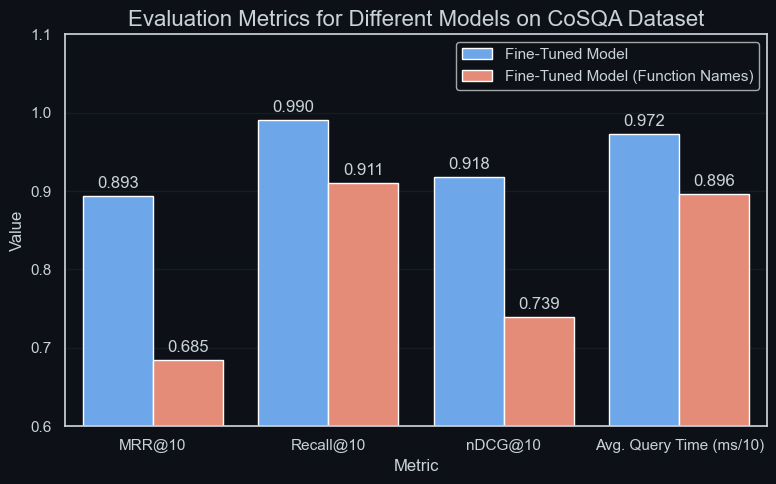

In [6]:
df = pd.read_csv("results/evaluation_fn_names.csv")
df["Avg. Query Time (ms/10)"] = df["Avg. Query Time (ms)"] / 10
df = df.melt(
    id_vars="Model",
    value_vars=["MRR@10", "Recall@10", "nDCG@10", "Avg. Query Time (ms/10)"],
    var_name="Metric",
    value_name="Value"
)

# plot_metrics_barplot(df,
#                      palette=[FT_LIGHT, FN_LIGHT],
#                      ylims=(0.6, 1.1),
#                      theme='light',
#                      save_path='assets/eval_fn_light.png'
# )
plot_metrics_barplot(df,
                     palette=[FT_DARK, FN_DARK],
                     ylims=(0.6, 1.1),
                     theme='dark',
                     save_path='assets/eval_fn_dark.png'
)